# **INTRODUCTION**

> I will implement and train the CNN model using the Fashion-MNIST dataset in this notebook. Then I will implement both the AlexNet and ResNet architectures of CNN and train the models.

## **IMPORTING NECESSARY MODULES**

> This section imports all the required modules for the code.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

In [3]:
import torch
from torch import optim, nn
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset

## **DATA PREPARATION**

> The dataset is reshaped and normalized to prepare it for further training of the model in this section.


In [4]:
train_unpreprocessed = pd.read_csv('fashion-mnist_train.csv')
test_unpreprocessed = pd.read_csv('fashion-mnist_test.csv')

In [5]:
X_train, y_train = train_unpreprocessed.iloc[:, 1:], train_unpreprocessed.iloc[:, 0]
X_test, y_test = test_unpreprocessed.iloc[:, 1:], test_unpreprocessed.iloc[:, 0]

In [6]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X_train_np = X_train.to_numpy() if hasattr(X_train, 'to_numpy') else X_train
X_test_np = X_test.to_numpy() if hasattr(X_test, 'to_numpy') else X_test
print("Global min pixel value:", np.min(X_train_np))
print("Global max pixel value:", np.max(X_train_np))

X_train shape: (60000, 784)
X_test shape: (10000, 784)
Global min pixel value: 0
Global max pixel value: 255


In [7]:
X_train_np = X_train_np / 255.0
X_test_np = X_test_np / 255.0
X_train = X_train_np.reshape(-1, 28, 28, 1)
X_test = X_test_np.reshape(-1, 28, 28, 1)

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

In [9]:
print("Global min pixel value:", np.min(X_train))
print("Global max pixel value:", np.max(X_train))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Global min pixel value: 0.0
Global max pixel value: 1.0
X_train shape: (54000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)


## **IMPLEMENTING CNN**

> I will implement two CNN models: AlexNet using TensorFlow and ResNet using PyTorch. Then I will train the models on the training sets and test them on the testing sets. Subsequently, I will compare the models based on the prediction accuracies.

### *AlexNet using TensorFlow*

MODEL CLASS

In [10]:
class AlexNetFashionMNIST():
    def __init__(self, input_shape, num_classes):
        self.input_shape = input_shape
        self.num_classes = num_classes
    def build(self):
        model = models.Sequential()
        model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=self.input_shape))
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))
        model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu'))
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))
        model.add(layers.Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'))
        model.add(layers.Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'))
        model.add(layers.Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))
        model.add(layers.Flatten())
        model.add(layers.Dense(512, activation='relu'))
        model.add(layers.Dropout(0.5))
        model.add(layers.Dense(256, activation='relu'))
        model.add(layers.Dropout(0.5))
        model.add(layers.Dense(self.num_classes, activation='softmax'))
        return model

TRAINER CLASS

In [11]:
class Trainer:
    def __init__(self, model, X_train, y_train, X_val, y_val):
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.history = None
    def compile_model(self):
        self.model.compile(
            optimizer=optimizers.Adam(),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
    def train(self, epochs=20, batch_size=64):
        self.history = self.model.fit(
            self.X_train, self.y_train,
            validation_data=(self.X_val, self.y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=2
        )
    def plot_history(self):
        if self.history is None:
            print("Train the model before plotting.")
            return
        acc = self.history.history['accuracy']
        val_acc = self.history.history['val_accuracy']
        loss = self.history.history['loss']
        val_loss = self.history.history['val_loss']
        epochs = range(1, len(acc) + 1)
        plt.figure(figsize=(14, 5))
        plt.subplot(1, 2, 1)
        plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
        plt.plot(epochs, val_acc, 'r^-', label='Validation Accuracy')
        plt.title('Accuracy Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.plot(epochs, loss, 'bo-', label='Training Loss')
        plt.plot(epochs, val_loss, 'r^-', label='Validation Loss')
        plt.title('Loss Over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.tight_layout()
        plt.show()

TESTING CLASS

In [12]:
class Tester:
    def __init__(self, model, X_test, y_test):
        self.model = model
        self.X_test = X_test
        self.y_test = y_test
    def evaluate(self):
        test_loss, test_acc = self.model.evaluate(self.X_test, self.y_test, verbose=2)
        print(f"\nTest Accuracy: {test_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}")

MODEL IMPLEMENTATION

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
844/844 - 403s - 477ms/step - accuracy: 0.7669 - loss: 0.6239 - val_accuracy: 0.8717 - val_loss: 0.3468
Epoch 2/20
844/844 - 436s - 516ms/step - accuracy: 0.8723 - loss: 0.3586 - val_accuracy: 0.8833 - val_loss: 0.3250
Epoch 3/20
844/844 - 443s - 525ms/step - accuracy: 0.8914 - loss: 0.2987 - val_accuracy: 0.9033 - val_loss: 0.2747
Epoch 4/20
844/844 - 442s - 523ms/step - accuracy: 0.9070 - loss: 0.2604 - val_accuracy: 0.8997 - val_loss: 0.2711
Epoch 5/20
844/844 - 441s - 522ms/step - accuracy: 0.9164 - loss: 0.2346 - val_accuracy: 0.9093 - val_loss: 0.2542
Epoch 6/20
844/844 - 442s - 524ms/step - accuracy: 0.9247 - loss: 0.2091 - val_accuracy: 0.9128 - val_loss: 0.2420
Epoch 7/20
844/844 - 445s - 527ms/step - accuracy: 0.9304 - loss: 0.1930 - val_accuracy: 0.9138 - val_loss: 0.2474
Epoch 8/20
844/844 - 439s - 520ms/step - accuracy: 0.9379 - loss: 0.1709 - val_accuracy: 0.9133 - val_loss: 0.2466
Epoch 9/20
844/844 - 442s - 523ms/step - accuracy: 0.9446 - loss: 0.1538 - val_a

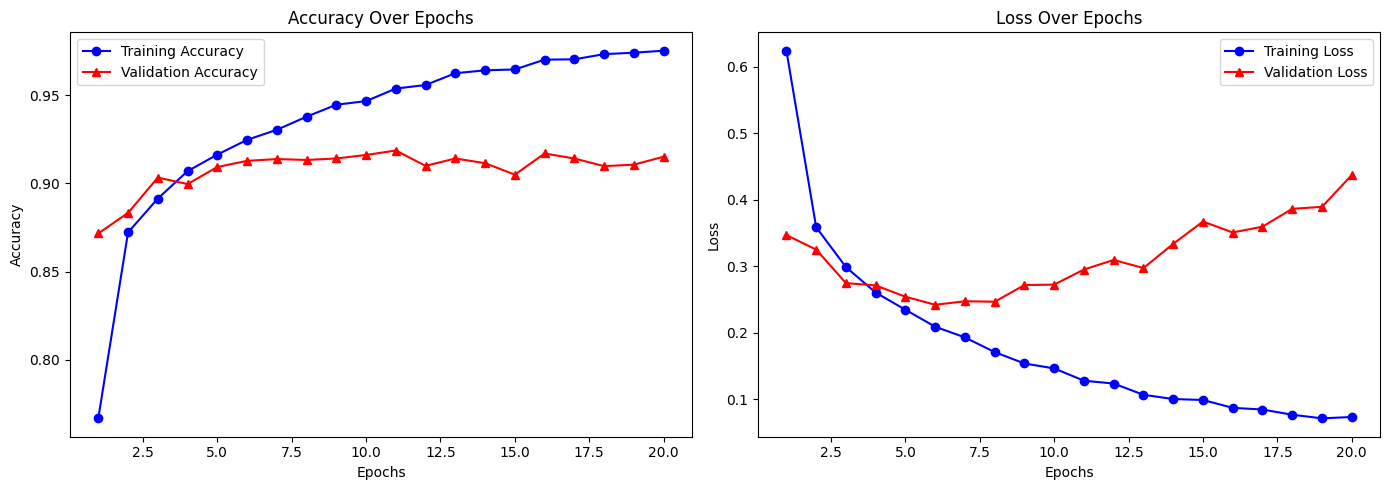

In [13]:
alexnet_builder = AlexNetFashionMNIST(input_shape=(28, 28, 1), num_classes=10)
model = alexnet_builder.build()
trainer = Trainer(model, X_train, y_train, X_val, y_val)
trainer.compile_model()
trainer.train(epochs=20)
trainer.plot_history()

MODEL EVALUATION

In [14]:
tester = Tester(model, X_test, y_test)
tester.evaluate()

313/313 - 18s - 57ms/step - accuracy: 0.9139 - loss: 0.4480

Test Accuracy: 0.9139
Test Loss: 0.4480


### *ResNet using Pytorch*

MODEL CLASS

In [15]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
    def forward(self, x):
        identity = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample:
            identity = self.downsample(x)
        out += identity
        return F.relu(out)

In [16]:
class ResNetFashionMNIST(nn.Module):
    def __init__(self, block=BasicBlock, layers=[2, 2, 2], num_classes=10):
        super(ResNetFashionMNIST, self).__init__()
        self.in_channels = 16
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, layers[0])
        self.layer2 = self._make_layer(block, 32, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 64, layers[2], stride=2)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)
    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        layers = [block(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(block(out_channels, out_channels))
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

TRAINING CLASS

In [17]:
class Trainer:
    def __init__(self, model, device, optimizer, train_loader, val_loader, criterion):
        self.model = model.to(device)
        self.device = device
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
    def train(self, epochs):
        for epoch in range(epochs):
            self.model.train()
            train_loss = 0
            correct = 0
            total = 0
            for images, labels in tqdm(self.train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
                images, labels = images.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                train_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            train_acc = correct / total
            val_acc, val_loss = self.evaluate()
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            self.history['train_loss'].append(train_loss / len(self.train_loader))
            self.history['val_loss'].append(val_loss)
            print(f"Epoch {epoch+1}: Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    def evaluate(self):
        self.model.eval()
        correct = 0
        total = 0
        val_loss = 0
        with torch.no_grad():
            for images, labels in self.val_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                val_loss += self.criterion(outputs, labels).item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        return correct / total, val_loss / len(self.val_loader)
    def plot_history(self):
        epochs = range(1, len(self.history['train_acc']) + 1)
        plt.figure(figsize=(14, 5))
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.history['train_acc'], 'b-', label='Train Accuracy')
        plt.plot(epochs, self.history['val_acc'], 'r-', label='Validation Accuracy')
        plt.title('Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.history['train_loss'], 'b-', label='Train Loss')
        plt.plot(epochs, self.history['val_loss'], 'r-', label='Validation Loss')
        plt.title('Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.tight_layout()
        plt.show()

TESTING CLASS

In [18]:
class Tester:
    def __init__(self, model, device, test_loader):
        self.model = model.to(device)
        self.device = device
        self.test_loader = test_loader
    def evaluate(self):
        self.model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in self.test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        print(f"Test Accuracy: {correct / total:.4f}")

MODEL IMPLEMENTATION

Using device: cpu


Epoch 1/20: 100%|██████████| 844/844 [04:13<00:00,  3.33it/s]


Epoch 1: Train Acc: 0.8324, Val Acc: 0.8743, Train Loss: 400.7960, Val Loss: 0.3448


Epoch 2/20: 100%|██████████| 844/844 [04:13<00:00,  3.33it/s]


Epoch 2: Train Acc: 0.8951, Val Acc: 0.8980, Train Loss: 244.8460, Val Loss: 0.2874


...

Epoch 18: Train Acc: 0.9830, Val Acc: 0.9133, Train Loss: 40.7453, Val Loss: 0.3100


Epoch 19/20: 100%|██████████| 844/844 [04:13<00:00,  3.33it/s]


Epoch 19: Train Acc: 0.9826, Val Acc: 0.9177, Train Loss: 40.6406, Val Loss: 0.3130


Epoch 20/20: 100%|██████████| 844/844 [04:10<00:00,  3.37it/s]


Epoch 20: Train Acc: 0.9842, Val Acc: 0.9215, Train Loss: 35.7073, Val Loss: 0.3132


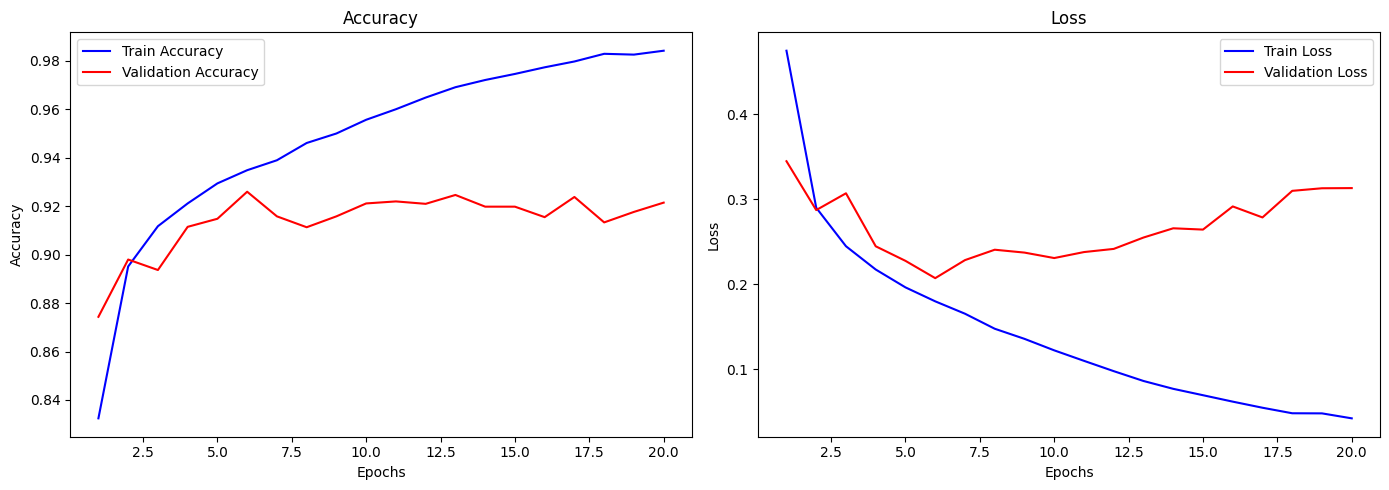

In [19]:
X_train_tensor = torch.tensor(X_train).permute(0, 3, 1, 2).float()
X_val_tensor   = torch.tensor(X_val).permute(0, 3, 1, 2).float()
X_test_tensor  = torch.tensor(X_test).permute(0, 3, 1, 2).float()
y_train_tensor = torch.tensor(y_train.to_numpy()).long()
y_val_tensor   = torch.tensor(y_val.to_numpy()).long()
y_test_tensor  = torch.tensor(y_test.to_numpy()).long()
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64)
test_loader  = DataLoader(test_dataset, batch_size=64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = ResNetFashionMNIST()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
trainer = Trainer(model, device, optimizer, train_loader, val_loader, criterion)
trainer.train(epochs=20)
trainer.plot_history()

MODEL EVALUATION

In [20]:
tester = Tester(model, device, test_loader)
tester.evaluate()

Test Accuracy: 0.9287
